Understand Target Variable

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/Volumes/My Disk 1/Fourth Semester/CS3121 Introduction to Data Science/Project/Predicting_Malnutrition_Hotspots/final_dataset_2000_2022_long_year_order.csv')

In [4]:
df.columns

Index(['Country', 'Country Code', 'Year',
       'Predictor_01 - Food supply (kcal/capita/day)',
       'Predictor_02 - Protein supply quantity (g/capita/day)',
       'Predictor_03 - Fat supply quantity (g/capita/day)',
       'Predictor_04 - GDP per capita(current US$)',
       'Predictor_05 - HDI Value', 'Predictor_06 - Population Growth Rate(%)',
       'Predictor_07 - Food production index',
       'Predictor_08 - People using basic drinking water services (% of population)',
       'Predictor_09 - Prevalance of Maternal Anemia %', 'TV_01 - Stunting',
       'TV_02 - Prevalence_of_Overweight', 'Stunting_norm', 'Overweight_norm',
       'Raw_norm', 'Malnutrition_Index'],
      dtype='object')

In [5]:
print(df['Malnutrition_Index'].describe())

count    3128.000000
mean        0.351078
std         0.188830
min         0.000000
25%         0.206837
50%         0.323900
75%         0.482651
max         1.000000
Name: Malnutrition_Index, dtype: float64


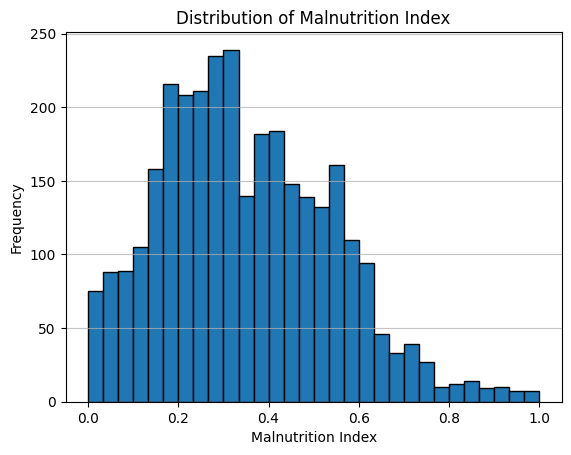

In [6]:
plt.hist(df['Malnutrition_Index'], bins=30, edgecolor='black')
plt.title('Distribution of Malnutrition Index')
plt.xlabel('Malnutrition Index')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show() 

In [7]:
print("Mean:", df['Malnutrition_Index'].mean())
print("Median:", df['Malnutrition_Index'].median())
print("Mode:", df['Malnutrition_Index'].mode().iloc[0])
print("Skewness:", df['Malnutrition_Index'].skew())

Mean: 0.35107808490089515
Median: 0.323899779
Mode: 0.063712976
Skewness: 0.49685128364823355


Correlation Analysis

In [8]:
df.drop(columns=['Stunting_norm','Overweight_norm','Raw_norm'], inplace=True)

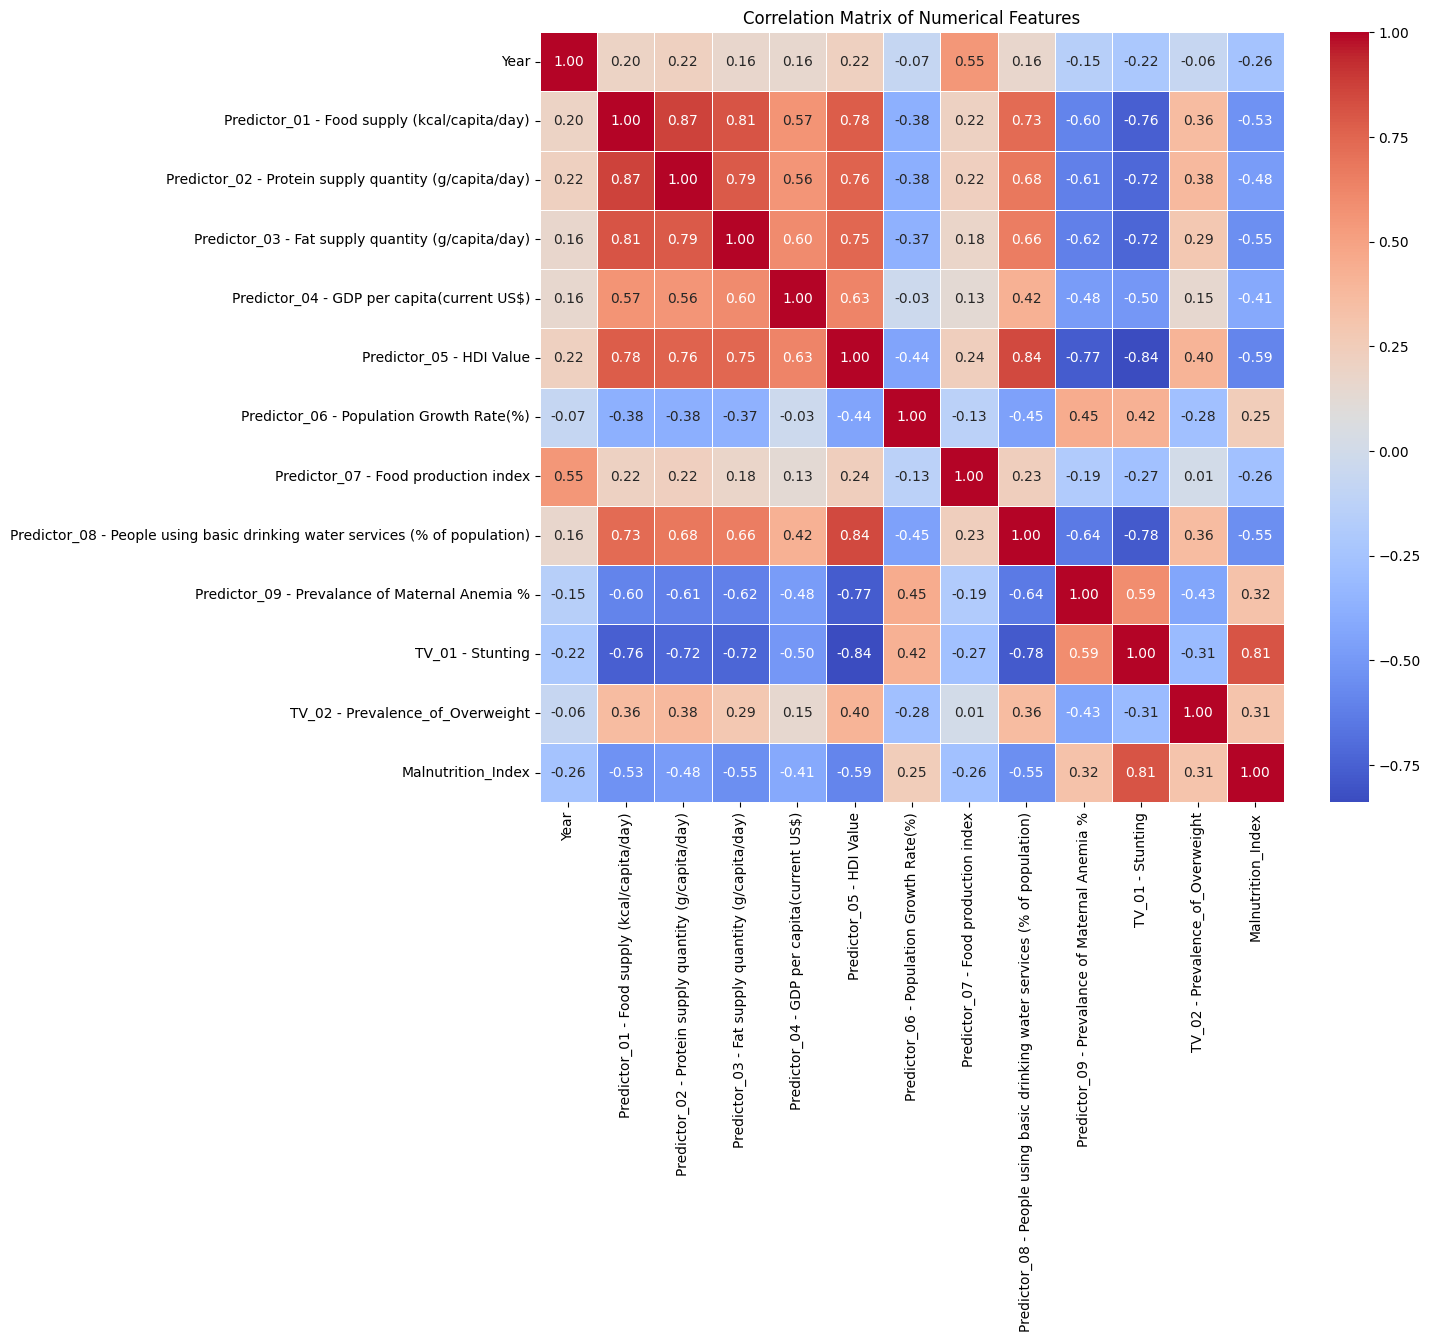

In [9]:
corr = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Predictor vs target relationships

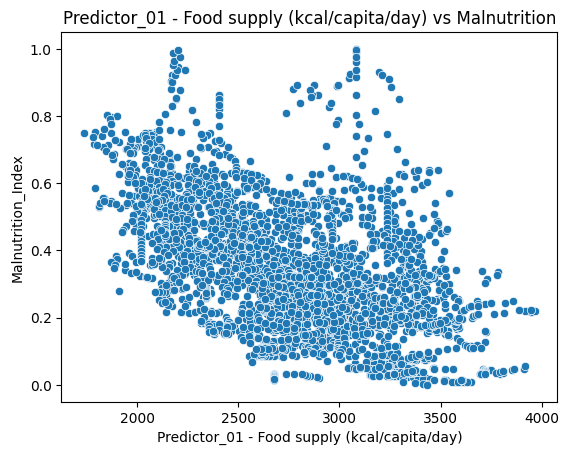

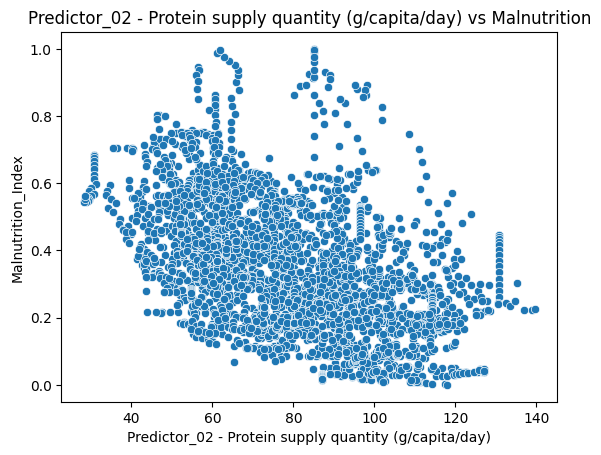

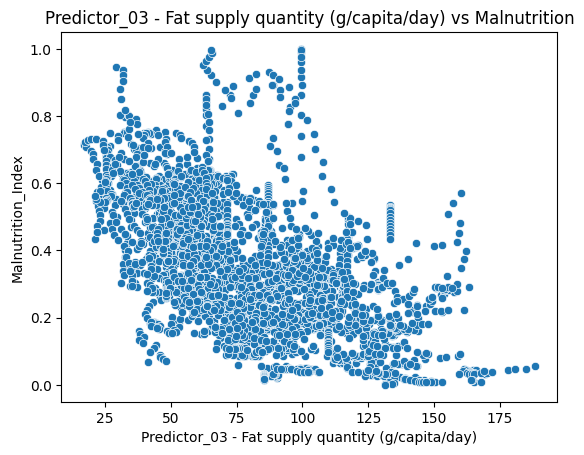

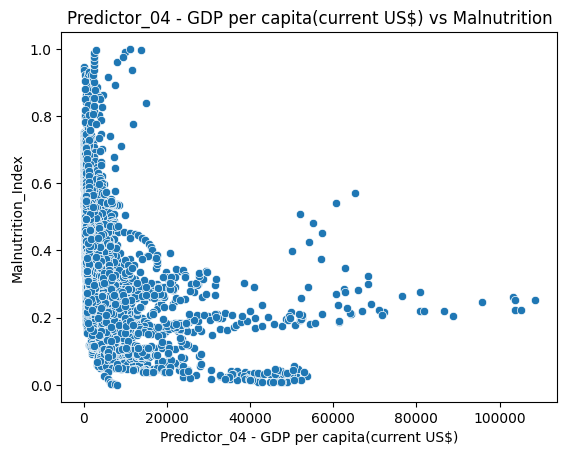

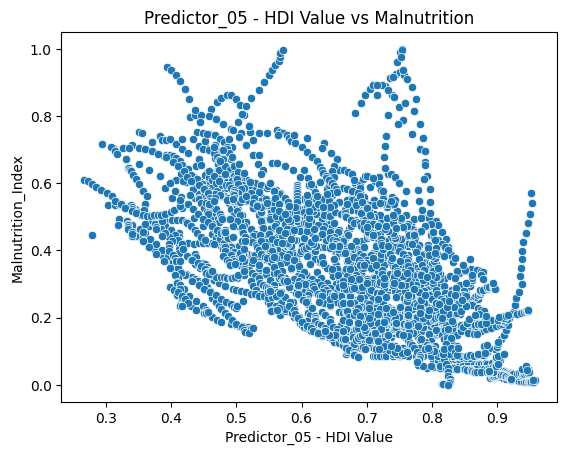

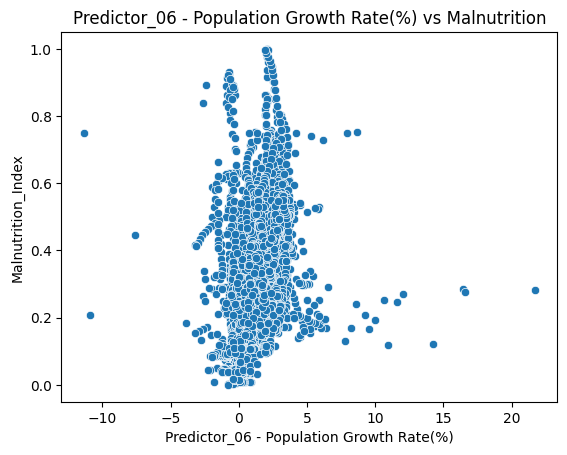

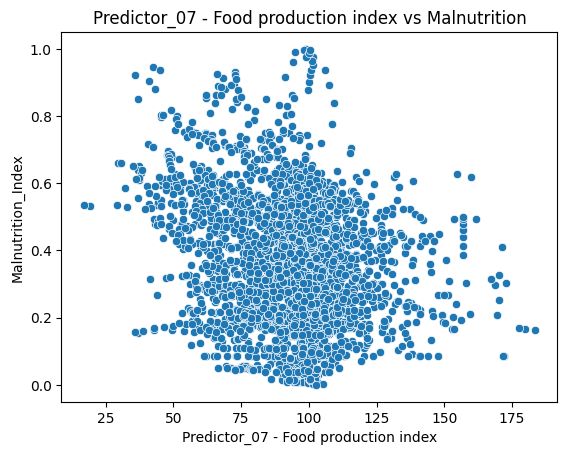

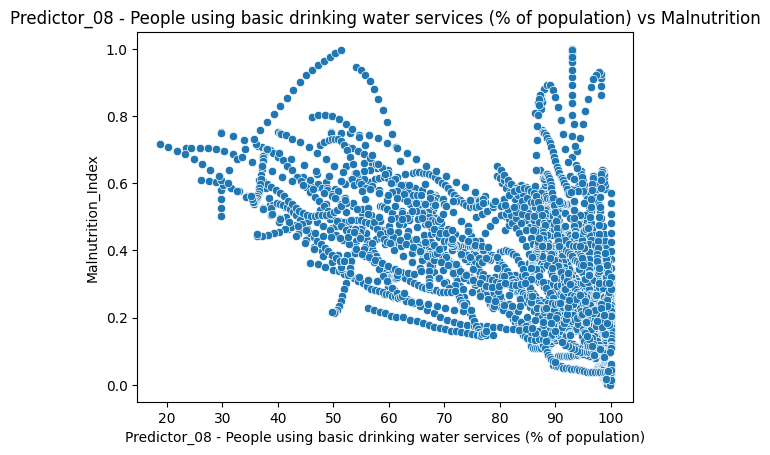

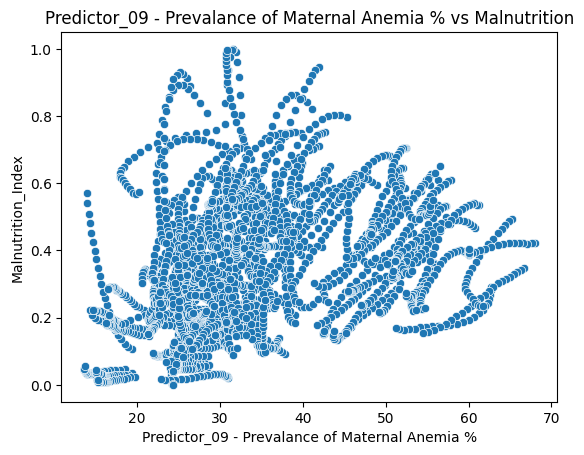

In [26]:
for dataset in ['Predictor_01 - Food supply (kcal/capita/day)',
       'Predictor_02 - Protein supply quantity (g/capita/day)',
       'Predictor_03 - Fat supply quantity (g/capita/day)',
       'Predictor_04 - GDP per capita(current US$)',
       'Predictor_05 - HDI Value', 'Predictor_06 - Population Growth Rate(%)',
       'Predictor_07 - Food production index',
       'Predictor_08 - People using basic drinking water services (% of population)',
       'Predictor_09 - Prevalance of Maternal Anemia %']:
    sns.scatterplot(x=df[dataset],y=df['Malnutrition_Index'])
    plt.title(f"{dataset} vs Malnutrition")
    plt.show()

Malnutrition trend over time

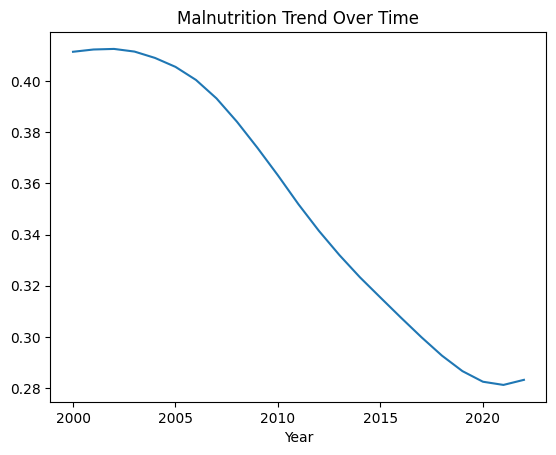

In [11]:
df.groupby('Year')['Malnutrition_Index'].mean().plot()
plt.title("Malnutrition Trend Over Time")
plt.show()

In [12]:
df.groupby('Country')['Malnutrition_Index'].mean().sort_values(ascending=False).head(10)

Country
Papua New Guinea    0.784820
Libya               0.713209
Ukraine             0.710685
Albania             0.673245
Guatemala           0.659977
Timor-Leste         0.658081
Malawi              0.657631
Zambia              0.632535
Yemen               0.631757
Afghanistan         0.629916
Name: Malnutrition_Index, dtype: float64

Univariate analysis of malnutrition index

In [13]:
country_mean = df.groupby('Country')['Malnutrition_Index'].mean()

In [14]:
top20_countries = country_mean.sort_values(ascending=False).head(20).index

In [25]:
print(top20_countries)

Index(['Papua New Guinea', 'Libya', 'Ukraine', 'Albania', 'Guatemala',
       'Timor-Leste', 'Malawi', 'Zambia', 'Yemen', 'Afghanistan', 'Mozambique',
       'Democratic Republic of the Congo', 'Comoros', 'Rwanda', 'Madagascar',
       'Lesotho', 'Ethiopia', 'Pakistan', 'Eswatini', 'Cameroon'],
      dtype='object', name='Country')


In [15]:
df_top20 = df[df['Country'].isin(top20_countries)]

/var/folders/fh/xg2jmmvs34nfjfqxrmv3wybw0000gn/T/ipykernel_73598/545977893.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


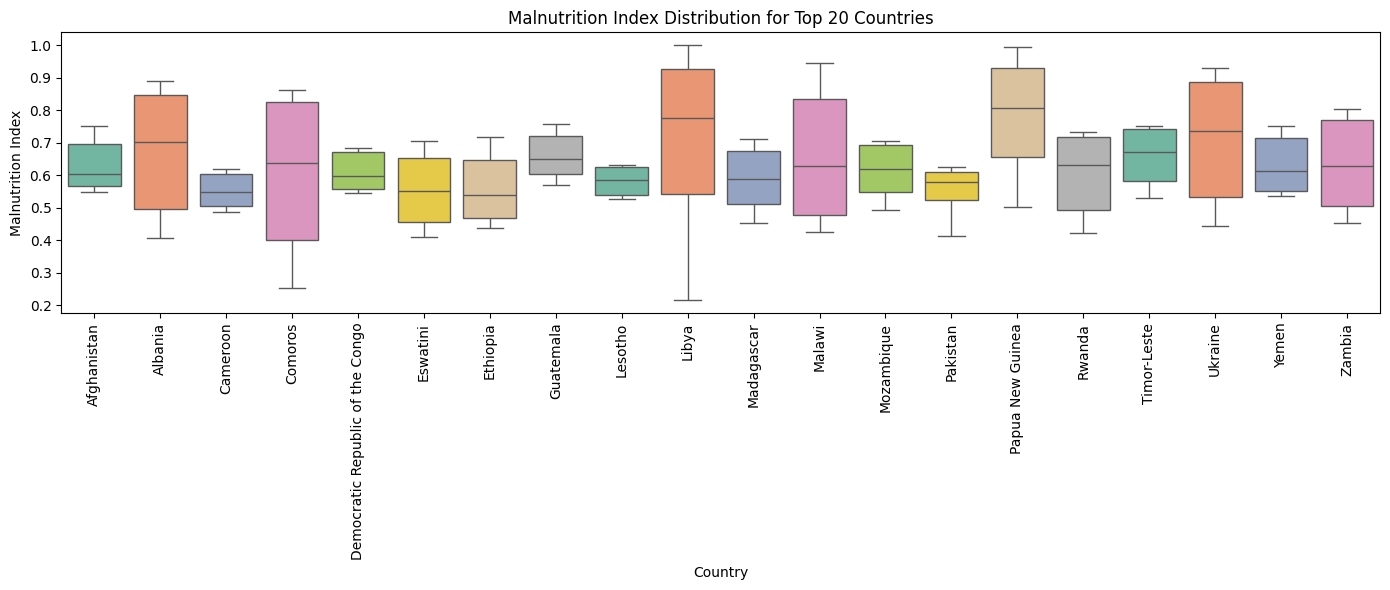

In [24]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='Country',
    y='Malnutrition_Index',
    data=df_top20,
    palette="Set2"
)

plt.xticks(rotation=90)
plt.title("Malnutrition Index Distribution for Top 20 Countries")
plt.xlabel("Country")
plt.ylabel("Malnutrition Index")

plt.tight_layout()
plt.show()

Box Plot 

In [27]:
df['food_supply_quartile'] = pd.qcut(
    df['Predictor_01 - Food supply (kcal/capita/day)'],
    4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)
df['hdi_group'] = df['Predictor_05 - HDI Value'].apply(
    lambda x: 'Low HDI' if x < 0.55 else 'High HDI'
)

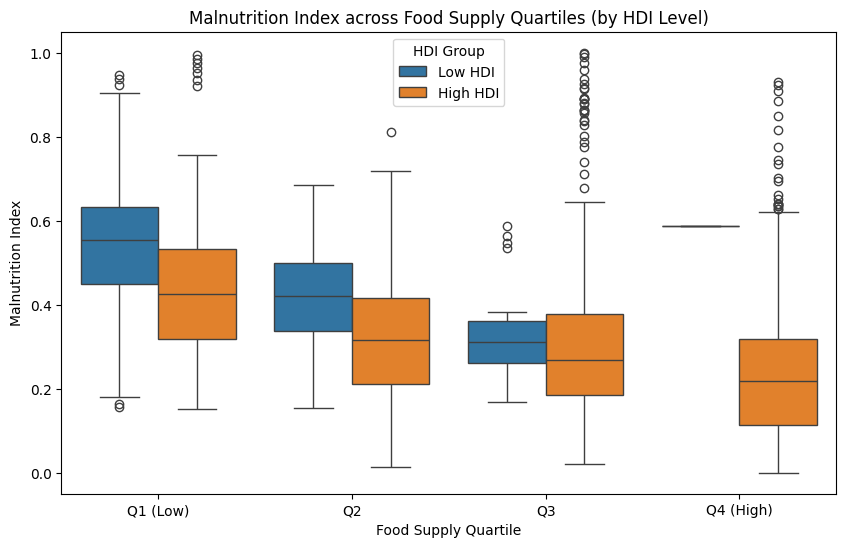

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='food_supply_quartile',
    y='Malnutrition_Index',
    hue='hdi_group',
    data=df
)

plt.title("Malnutrition Index across Food Supply Quartiles (by HDI Level)")
plt.xlabel("Food Supply Quartile")
plt.ylabel("Malnutrition Index")

plt.legend(title="HDI Group")
plt.show()

Choropleth map

In [31]:
%pip install plotly
import plotly.express as px

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 555.2 kB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
df_country = df.groupby(['Country', 'Country Code'])['Malnutrition_Index'].mean().reset_index()
fig = px.choropleth(
    df_country,
    locations="Country Code",       # ISO country code
    color="Malnutrition_Index",
    hover_name="Country",
    color_continuous_scale="Reds",
    title="Global Malnutrition Index (Hotspot Visualization)"
)
fig.show()


Choropleth map - add hotspots levels.

In [39]:
def classify_hotspot(x):
    if x < 0.15:
        return "Low"
    elif x < 0.30:
        return "Moderate"
    elif x < 0.40:
        return "Hotspot"
    else:
        return "Severe Hotspot"

In [40]:
df_country = df.groupby(['Country', 'Country Code'])['Malnutrition_Index'].mean().reset_index()
df_country['Hotspot_Level'] = df_country['Malnutrition_Index'].apply(classify_hotspot)

fig = px.choropleth(
    df_country,
    locations="Country Code",       # ISO country code
    color="Hotspot_Level",
    hover_name="Country",
    category_orders={"Hotspot_Level": ["Low", "Moderate", "Hotspot", "Severe Hotspot"]},
    color_discrete_map={
        "Low": "#fee5d9",
        "Moderate": "#fcae91",
        "Hotspot": "#fb6a4a",
        "Severe Hotspot": "#cb181d"
    },
    title="Global Malnutrition Hotspot Levels"
)
fig.show()


In [41]:
df.columns

Index(['Country', 'Country Code', 'Year',
       'Predictor_01 - Food supply (kcal/capita/day)',
       'Predictor_02 - Protein supply quantity (g/capita/day)',
       'Predictor_03 - Fat supply quantity (g/capita/day)',
       'Predictor_04 - GDP per capita(current US$)',
       'Predictor_05 - HDI Value', 'Predictor_06 - Population Growth Rate(%)',
       'Predictor_07 - Food production index',
       'Predictor_08 - People using basic drinking water services (% of population)',
       'Predictor_09 - Prevalance of Maternal Anemia %', 'TV_01 - Stunting',
       'TV_02 - Prevalence_of_Overweight', 'Malnutrition_Index',
       'food_supply_quartile', 'hdi_group'],
      dtype='object')

In [42]:
df_country['Hotspot_Level'].head()

0    Severe Hotspot
1    Severe Hotspot
2    Severe Hotspot
3    Severe Hotspot
4          Moderate
Name: Hotspot_Level, dtype: object

In [44]:
df_country['Hotspot_Level'].shape

(136,)